# Assignment 01 Introduction to Computational Biology BEE-102

## Importing Required Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import math

## Q1: Fragment Length Distribution Matching

C:\Users\AADIT\AppData\Local\Temp\ipykernel_18408\223574484.py:2: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  fragment_data = pd.read_csv('query.bed', sep='\t', header=None)


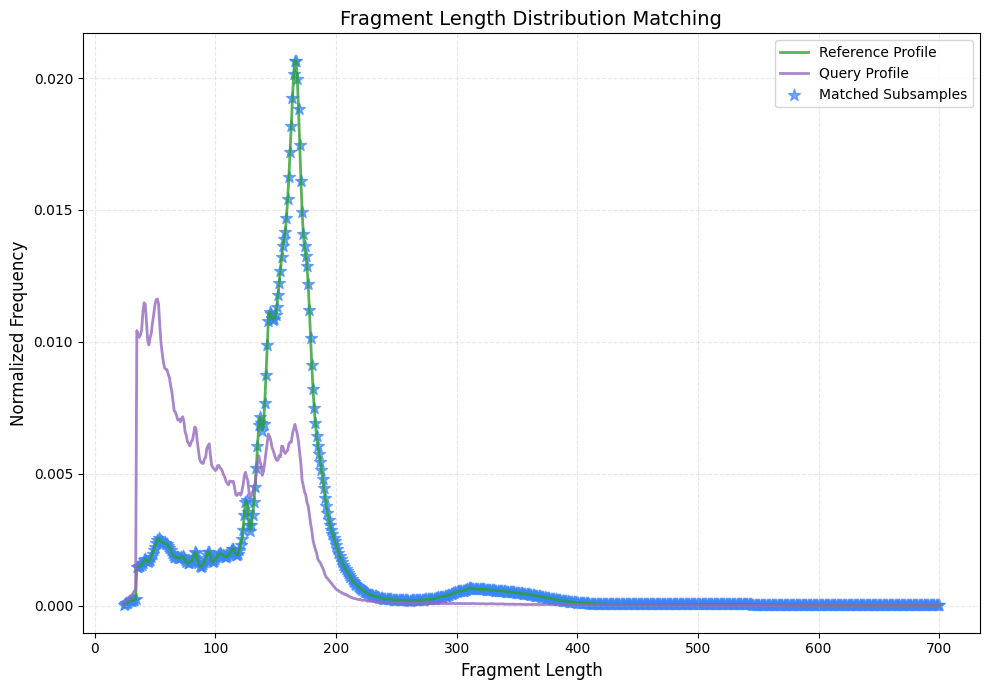

In [8]:
# Process query data
fragment_data = pd.read_csv('query.bed', sep='\t', header=None)
lengths = fragment_data.iloc[:, 2] - fragment_data.iloc[:, 1]
freq_counts = Counter(lengths)
total = sum(freq_counts.values())
normalized_dist = {length: count/total for length, count in freq_counts.items()}

# Create DataFrame with sorted values
x_values, y_values = zip(*sorted(normalized_dist.items()))
query_distribution = pd.DataFrame({'Length': x_values, 'Frequency': y_values})



# Load reference distribution
reference = pd.read_csv('reference.hist', sep='\t', header=None)



# Define binning parameters (keeping constants as specified)
bin_width = 10
min_val = 0
max_val = 720
bin_edges = list(range(min_val, max_val + bin_width, bin_width))
bin_names = [f"{i}-{i+bin_width}" for i in range(min_val, max_val, bin_width)]

# Assign bins to both distributions
query_distribution['bin'] = pd.cut(query_distribution['Length'], bins=bin_edges, 
                                  labels=bin_names, right=False)
reference['bin'] = pd.cut(reference.iloc[:,0], bins=bin_edges, 
                         labels=bin_names, right=False)

# Count entries in each bin
query_bin_counts = query_distribution['bin'].value_counts().sort_index()
ref_bin_counts = reference['bin'].value_counts().sort_index()

# Sample from reference to match query distribution
sampled_fragments = []
for bin_label in bin_names:
    q_count = query_bin_counts.get(bin_label, 0)
    r_count = ref_bin_counts.get(bin_label, 0)
    sample_count = min(q_count, r_count)
    
    if sample_count > 0:
        bin_data = reference[reference['bin'] == bin_label]
        samples = bin_data.sample(n=sample_count, random_state=42)
        sampled_fragments.append(samples)

# Combine samples
result = pd.concat(sampled_fragments, ignore_index=True)

# Create enhanced visualization
plt.figure(figsize=(10, 7))
plt.plot(reference.iloc[:,0], reference.iloc[:,1], color='#2ca02c', linewidth=2, 
         label='Reference Profile', alpha=0.8)
plt.plot(query_distribution['Length'], query_distribution['Frequency'], 
         color='#9467bd', linewidth=2, label='Query Profile', alpha=0.8)
plt.scatter(result.iloc[:,0], result.iloc[:,1], color='#3a86ff', 
            marker='*', s=80, alpha=0.7, label='Matched Subsamples')

plt.xlabel('Fragment Length', fontsize=12)
plt.ylabel('Normalized Frequency', fontsize=12)
plt.title('Fragment Length Distribution Matching', fontsize=14)
plt.grid(alpha=0.3, linestyle='--')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

Q2: Markov Transition Matrix for DNA Sequence

Markov Transition Matrix:
(Rows: current base → Columns: next base)
        A    C    G     T
A  0.0625  0.1  0.2  0.52
C  0.2500  0.0  0.2  0.16
G  0.1250  0.0  0.2  0.12
T  0.5625  0.9  0.4  0.20


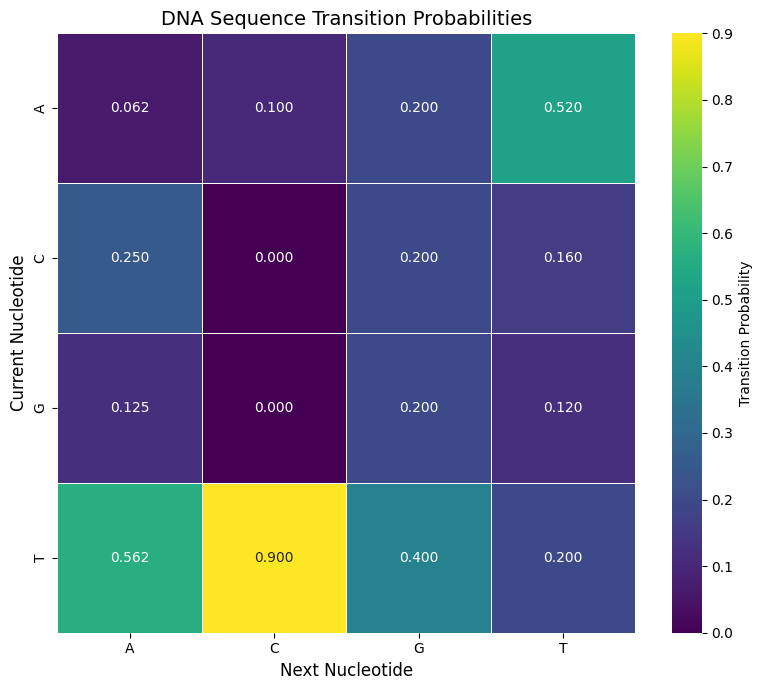

In [9]:
# Define bases and initialize matrix
nucleotides = ['A', 'C', 'G', 'T']
transition_counts = {base1: {base2: 0 for base2 in nucleotides} for base1 in nucleotides}

dna_sequence = "CTAGTTCAGTTATTAATCTGGCTTATATACTGACTACTATATCTCTTATATATACTG"

# Count transitions between consecutive bases
for i in range(len(dna_sequence)-1):
    current = dna_sequence[i]
    next_base = dna_sequence[i+1]
    if current in nucleotides and next_base in nucleotides:
        transition_counts[current][next_base] += 1

# Calculate probabilities
matrix = {}
for base1 in nucleotides:
    total = sum(transition_counts[base1].values())
    if total > 0:
        matrix[base1] = {base2: transition_counts[base1][base2]/total for base2 in nucleotides}
    else:
        matrix[base1] = {base2: 0.0 for base2 in nucleotides}

# Convert to DataFrame
transition_matrix = pd.DataFrame(matrix)

# Display with enhanced formatting
print("Markov Transition Matrix:")
print("(Rows: current base → Columns: next base)")
print(transition_matrix.round(4))

# Create heatmap visualization
plt.figure(figsize=(8, 7))
sns.heatmap(transition_matrix, annot=True, fmt='.3f', cmap='viridis', 
            linewidths=0.5, cbar_kws={'label': 'Transition Probability'})
plt.title('DNA Sequence Transition Probabilities', fontsize=14)
plt.xlabel('Next Nucleotide', fontsize=12)
plt.ylabel('Current Nucleotide', fontsize=12)
plt.tight_layout()
plt.show()

Q3: Multi-line to Single-line FASTA Converter

In [10]:
def fasta_converter(input_path, output_path):
    current_header = None
    sequence_lines = []
    
    with open(input_path, 'r') as infile, open(output_path, 'w') as outfile:
        for line in infile:
            line = line.strip()
            
            if line.startswith('>'):  # Header line
                # Write previous sequence if it exists
                if current_header:
                    outfile.write(current_header + '\n')
                    outfile.write(''.join(sequence_lines) + '\n')
                
                # Start new sequence
                current_header = line
                sequence_lines = []
            elif line: 
                sequence_lines.append(line)
        
        
        if current_header:
            outfile.write(current_header + '\n')
            outfile.write(''.join(sequence_lines) + '\n')
    
    print(f"Converted FASTA file saved to: {output_path}")

# File paths (kept as specified)
input_file = "multiline_input.fasta"
output_file = "output.fasta"

fasta_converter(input_file, output_file)

Converted FASTA file saved to: output.fasta


Q4: Viterbi Algorithm Implementation

Log probability of given path: -41.22
Viterbi best log probability: -38.68
Most likely path: EEEEEEEEEEEEEEEEEEEEEEEEEE


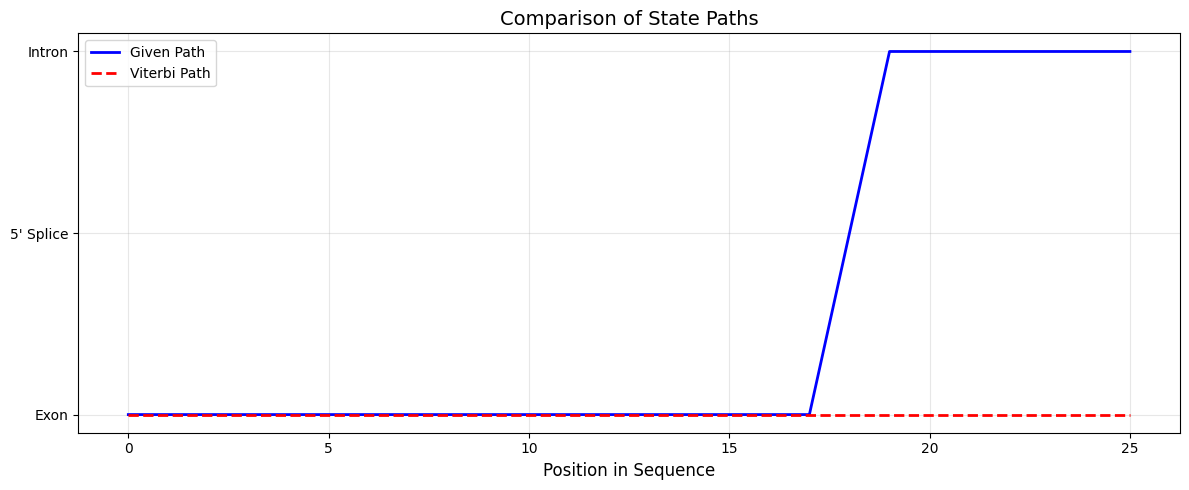

In [11]:
# Model parameters (kept as specified)
states = ['E', '5', 'I']
start_prob = {'E': 1.0, '5': 0.0, 'I': 0.0}
trans_prob = {
    'E': {'E': 0.9, '5': 0.1},
    '5': {'I': 1.0},
    'I': {'I': 0.9, 'end': 0.1}
}
emit_prob = {
    'E': {'A': 0.25, 'C': 0.25, 'G': 0.25, 'T': 0.25},
    '5': {'A': 0.05, 'C': 0.0, 'G': 0.95, 'T': 0.0},
    'I': {'A': 0.4, 'C': 0.1, 'G': 0.1, 'T': 0.4}
}

def safe_log(value):
    """Log function that handles zero values"""
    return float('-inf') if value == 0 else math.log(value)

def calculate_path_likelihood(path, sequence):
    """Calculate log probability of a specific path"""
    if len(path) != len(sequence):
        raise ValueError("Path and sequence lengths must match")
    
    log_prob = 0.0
    
    # Calculate probability components
    for i in range(len(sequence)):
        state = path[i]
        symbol = sequence[i]
        
        # Initial state probability
        if i == 0:
            log_prob += safe_log(start_prob[state])
        else:
            # Transition probability
            prev_state = path[i-1]
            log_prob += safe_log(trans_prob[prev_state].get(state, 0))
        
        # Emission probability
        log_prob += safe_log(emit_prob[state].get(symbol, 0))
    
    # End state transition if applicable
    if path[-1] == 'I':
        log_prob += safe_log(trans_prob['I']['end'])
    
    return log_prob

def viterbi_decode(sequence):
    """Implement Viterbi algorithm to find most likely path"""
    T = len(sequence)
    viterbi_matrix = [{}]
    backpointers = {}
    
    # Initialize (t=0)
    for state in states:
        initial_prob = safe_log(start_prob[state])
        emit = safe_log(emit_prob[state].get(sequence[0], 0))
        viterbi_matrix[0][state] = initial_prob + emit
        backpointers[state] = [state]
    
    # Dynamic programming loop
    for t in range(1, T):
        viterbi_matrix.append({})
        new_backpointers = {}
        
        for current in states:
            max_prob = float('-inf')
            best_prev = None
            
            for previous in states:
                if current in trans_prob.get(previous, {}):
                    # Calculate probability through this path
                    prob = (viterbi_matrix[t-1][previous] + 
                           safe_log(trans_prob[previous][current]) +
                           safe_log(emit_prob[current].get(sequence[t], 0)))
                    
                    if prob > max_prob:
                        max_prob = prob
                        best_prev = previous
            
            viterbi_matrix[t][current] = max_prob
            
            if best_prev:
                new_backpointers[current] = backpointers[best_prev] + [current]
            else:
                new_backpointers[current] = [current]
        
        backpointers = new_backpointers
    
    # Find the best final state
    final_t = T - 1
    best_final_prob = float('-inf')
    best_final_state = None
    
    for state in states:
        if viterbi_matrix[final_t][state] > best_final_prob:
            best_final_prob = viterbi_matrix[final_t][state]
            best_final_state = state
    
    best_path = ''.join(backpointers[best_final_state])
    return best_path, best_final_prob

# Example data (kept as specified)
example_path = "EEEEEEEEEEEEEEEEEE5IIIIIII"
example_sequence = "CTTCATGTGAAAGCAGACGTAAGTCA"

# Calculate log probability of the given path
path_logp = calculate_path_likelihood(example_path, example_sequence)
print(f"Log probability of given path: {path_logp:.2f}")

# Find the most likely path using Viterbi
optimal_path, optimal_logp = viterbi_decode(example_sequence)
print(f"Viterbi best log probability: {optimal_logp:.2f}")
print(f"Most likely path: {optimal_path}")

# Visualize results
plt.figure(figsize=(12, 5))
plt.plot(range(len(example_path)), 
         [{'E':0, '5':1, 'I':2}[s] for s in example_path], 
         'b-', lw=2, label='Given Path')
plt.plot(range(len(optimal_path)), 
         [{'E':0, '5':1, 'I':2}[s] for s in optimal_path], 
         'r--', lw=2, label='Viterbi Path')
plt.yticks([0, 1, 2], ['Exon', '5\' Splice', 'Intron'])
plt.xlabel('Position in Sequence', fontsize=12)
plt.title('Comparison of State Paths', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Q5: V-Plot Generation

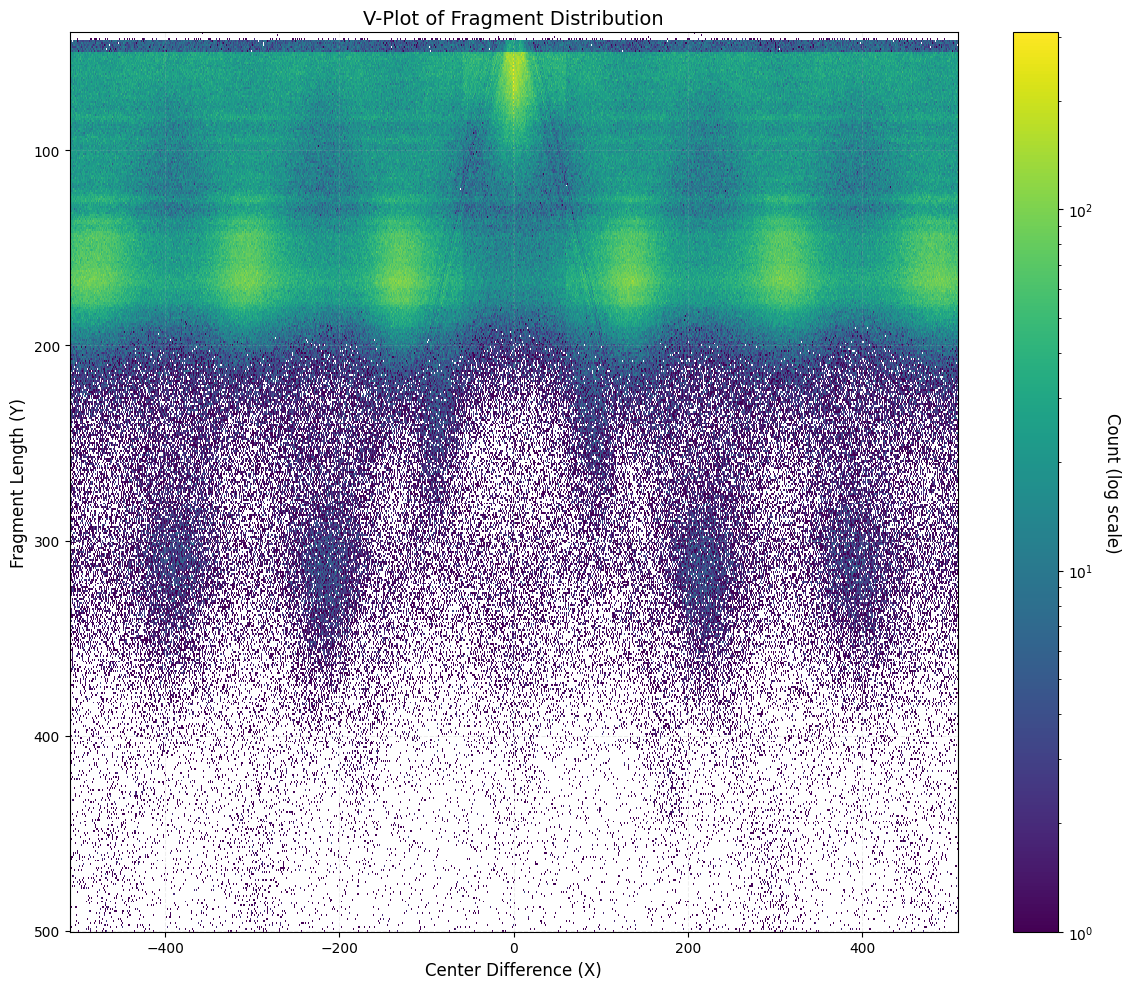

Total unique coordinates: 280653


In [12]:
def generate_v_plot(bed_file):
    """Generate V-plot from mapped.bed data"""
    # Count (X,Y) coordinate occurrences
    coordinates = {}
    
    with open(bed_file, 'r') as file:
        for line in file:
            cols = line.strip().split('\t')
            
            # Calculate midpoints and values
            midpoint1 = (int(cols[2]) + int(cols[3])) / 2
            midpoint2 = (int(cols[8]) + int(cols[9])) / 2
            
            x_coord = int(midpoint2 - midpoint1)
            y_coord = int(int(cols[9]) - int(cols[8]))
            
            # Count occurrences
            if (x_coord, y_coord) in coordinates:
                coordinates[(x_coord, y_coord)] += 1
            else:
                coordinates[(x_coord, y_coord)] = 1
    
    # Extract unique coordinates and values
    unique_x = sorted(set(x for x, y in coordinates))
    unique_y = sorted(set(y for x, y in coordinates))
    
    # Create matrix for heatmap
    matrix = np.zeros((len(unique_y), len(unique_x)))
    
    # Position mapping
    x_pos = {val: idx for idx, val in enumerate(unique_x)}
    y_pos = {val: idx for idx, val in enumerate(unique_y)}
    
    # Fill matrix
    for (x, y), count in coordinates.items():
        matrix[y_pos[y], x_pos[x]] = count
    
    # Create enhanced V-plot visualization
    plt.figure(figsize=(12, 10))
    
    # Use viridis colormap with log scaling for better visibility
    v_plot = plt.pcolormesh(unique_x, unique_y, matrix, cmap='viridis', 
                         norm=plt.cm.colors.LogNorm())
    
    # Add colorbar and styling
    cbar = plt.colorbar(v_plot)
    cbar.set_label('Count (log scale)', rotation=270, labelpad=20, fontsize=12)
    
    plt.xlabel('Center Difference (X)', fontsize=12)
    plt.ylabel('Fragment Length (Y)', fontsize=12)
    plt.title('V-Plot of Fragment Distribution', fontsize=14)
    plt.gca().invert_yaxis()  # Traditional V-plot orientation
    
    plt.grid(alpha=0.2, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    print(f"Total unique coordinates: {len(coordinates)}")
    return matrix

# Generate V-plot from the mapped.bed file
matrix = generate_v_plot("mapped.bed")

Q6: Gene Expression PCA Analysis

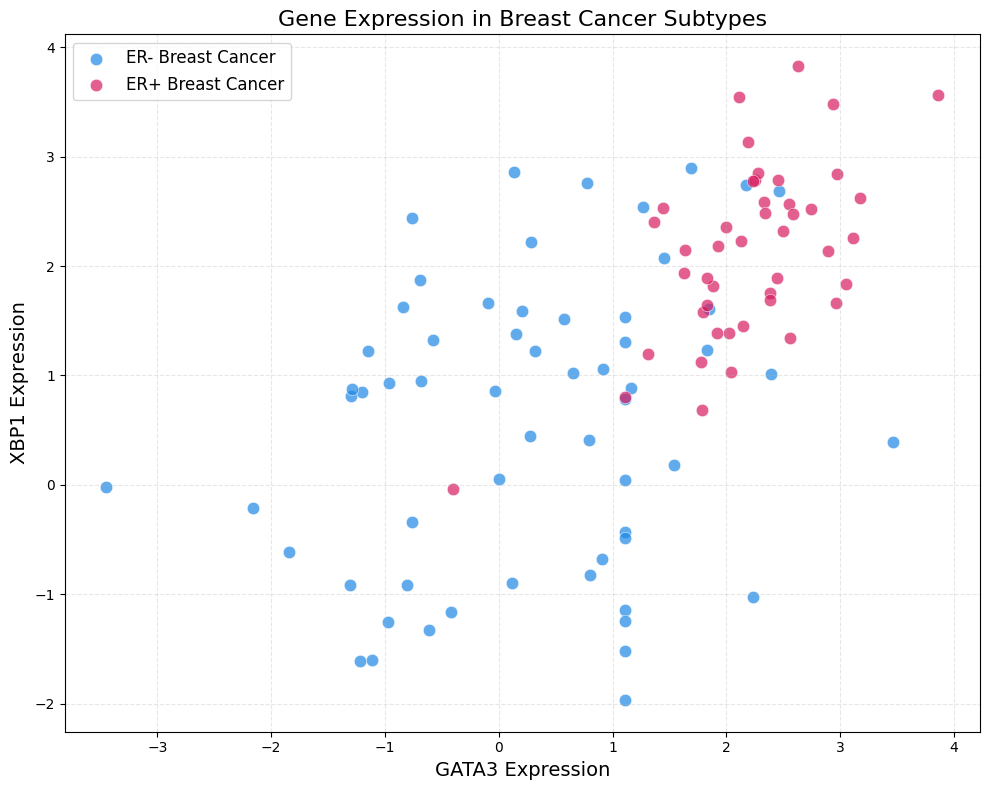

[3.07186142 0.87054073]


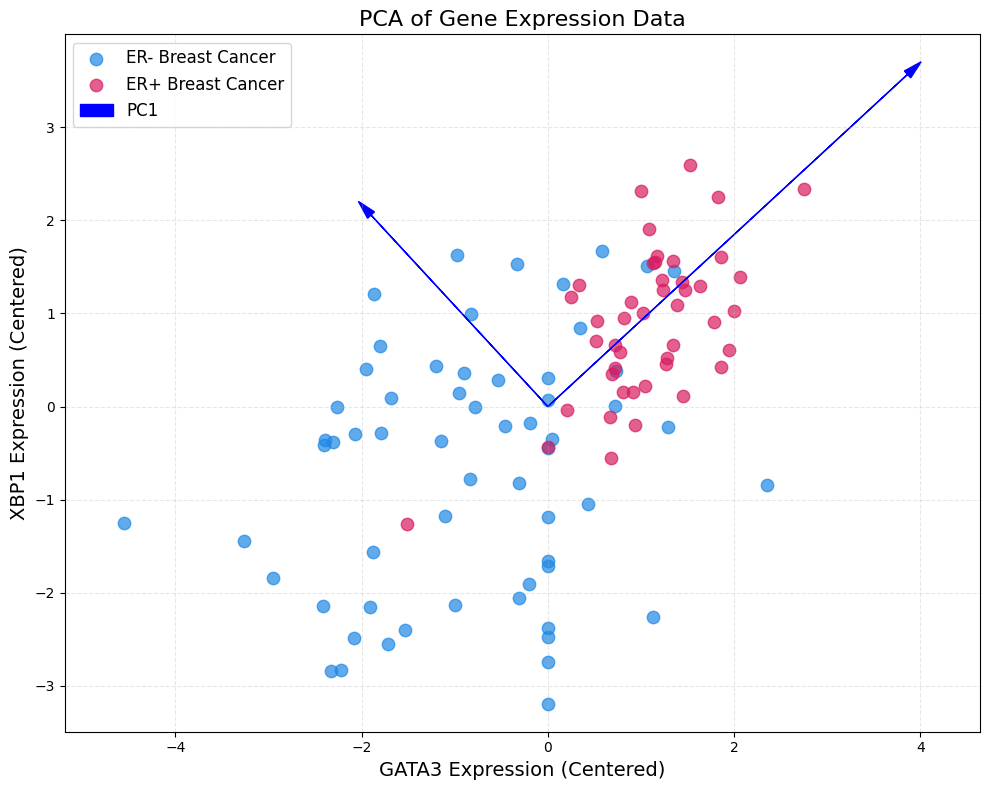

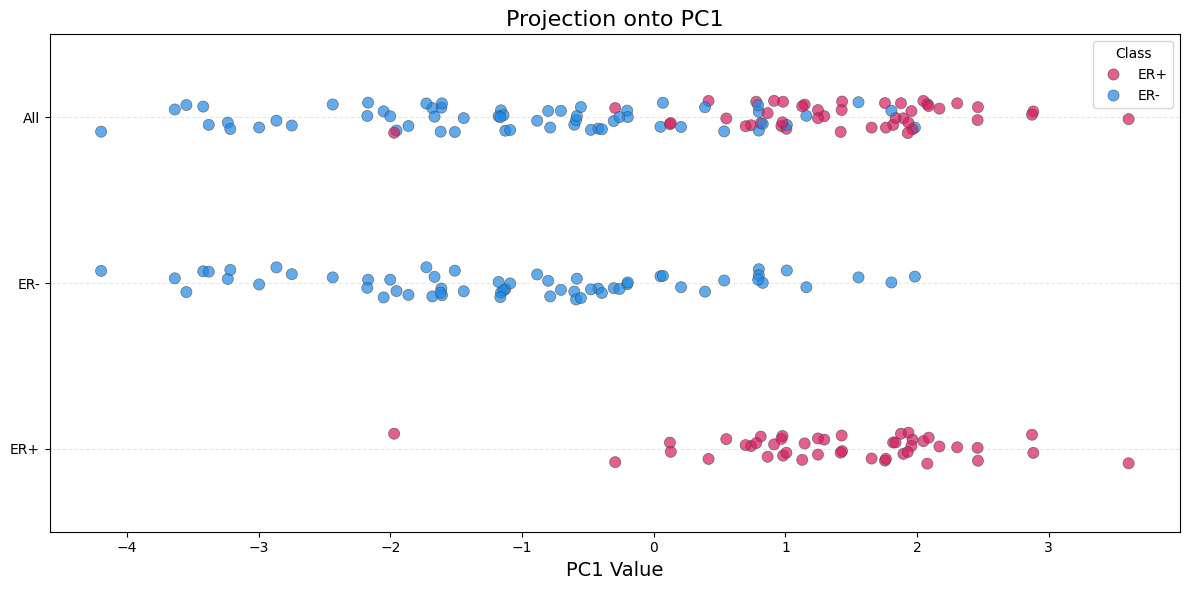

In [14]:
# Load data files
expression_data = pd.read_csv("filtered.tsv", sep="\t")
class_data = pd.read_csv("class.tsv", sep="\t", header=None)
gene_info = pd.read_csv("columns.tsv", sep="\t", comment="#")

# Find IDs for genes of interest
gata3_id = str(gene_info.loc[gene_info['GeneSymbol'] == 'GATA3', 'ID'].values[0])
xbp1_id = str(gene_info.loc[gene_info['GeneSymbol'] == 'XBP1', 'ID'].values[0])

# Format column names
gata3_col = " " + gata3_id
xbp1_col = " " + xbp1_id

# Extract expression values
gata3_expr = expression_data[gata3_col].values
xbp1_expr = expression_data[xbp1_col].values
classes = class_data[0].values

# Create beautiful scatter plot
plt.figure(figsize=(10, 8))

# Plot with enhanced styling
er_neg = (classes == 0)
er_pos = (classes == 1)

plt.scatter(gata3_expr[er_neg], xbp1_expr[er_neg], 
           color='#1E88E5', s=80, alpha=0.7, edgecolors='w', linewidth=0.5,
           label='ER- Breast Cancer')
plt.scatter(gata3_expr[er_pos], xbp1_expr[er_pos], 
           color='#D81B60', s=80, alpha=0.7, edgecolors='w', linewidth=0.5,
           label='ER+ Breast Cancer')

plt.xlabel('GATA3 Expression', fontsize=14)
plt.ylabel('XBP1 Expression', fontsize=14)
plt.title('Gene Expression in Breast Cancer Subtypes', fontsize=16)
plt.grid(alpha=0.3, linestyle='--')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Perform PCA analysis
expression_matrix = np.column_stack((gata3_expr, xbp1_expr))
centered_data = expression_matrix - np.mean(expression_matrix, axis=0)

# Calculate covariance matrix and eigen decomposition
cov_matrix = np.cov(centered_data.T)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort by eigenvalue
sort_idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]

# Print eigenvalues
print(eigenvalues)

# Plot data with PC vectors
plt.figure(figsize=(10, 8))
plt.scatter(centered_data[er_neg, 0], centered_data[er_neg, 1], 
           color='#1E88E5', s=80, alpha=0.7, label='ER- Breast Cancer')
plt.scatter(centered_data[er_pos, 0], centered_data[er_pos, 1], 
           color='#D81B60', s=80, alpha=0.7, label='ER+ Breast Cancer')

# Add principal component vectors
scale = 3
for i in range(2):
    plt.arrow(0, 0, 
             eigenvectors[0, i] * np.sqrt(eigenvalues[i]) * scale,
             eigenvectors[1, i] * np.sqrt(eigenvalues[i]) * scale,
             head_width=0.1, head_length=0.2, fc='blue', ec='blue',
             label=f'PC{i+1}' if i == 0 else "_nolegend_")

plt.xlabel('GATA3 Expression (Centered)', fontsize=14)
plt.ylabel('XBP1 Expression (Centered)', fontsize=14)
plt.title('PCA of Gene Expression Data', fontsize=16)
plt.grid(alpha=0.3, linestyle='--')
plt.legend(fontsize=12)
plt.axis('equal')
plt.tight_layout()
plt.show()

# Project data onto PC1
pc1_projection = centered_data @ eigenvectors[:, 0]

# Create visualization of projections
plt.figure(figsize=(12, 6))

# Create data for strip plot
projection_df = pd.DataFrame({
    'PC1': np.concatenate([pc1_projection, pc1_projection[er_neg], pc1_projection[er_pos]]),
    'Group': np.concatenate([
        ['All'] * len(pc1_projection),
        ['ER-'] * sum(er_neg),
        ['ER+'] * sum(er_pos)
    ]),
    'Class': np.concatenate([
        np.where(classes == 0, 'ER-', 'ER+'),
        ['ER-'] * sum(er_neg),
        ['ER+'] * sum(er_pos)
    ])
})

# Create enhanced strip plot
sns.stripplot(data=projection_df, x='PC1', y='Group', hue='Class',
             palette={'ER-': '#1E88E5', 'ER+': '#D81B60'},
             size=8, jitter=True, alpha=0.7, linewidth=0.5)

plt.title('Projection onto PC1', fontsize=16)
plt.xlabel('PC1 Value', fontsize=14)
plt.ylabel('')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()